# Plateau’s Problem (or minimal surface problem)

This notebook provides an implementation of the Plateau's problem, which finds a minimal surface shape that connects a set of interfaces.
More details on this example, can be found in [our paper](https://arxiv.org/abs/2402.14009), Sections 4.1 and A.2.

### Imports and setup

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch import nn
from tqdm.notebook import trange
import k3d
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from external.preconditioning.gram_factory import compute_gram_matrix


torch.manual_seed(0)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
torch.set_default_device(device)

### Define the boundary rectangles

In [2]:
def get_boundary_angled_rectangles(n=1000):
    ls = lambda a,b : torch.linspace(a, b, n//8, device=device)
    const = lambda c : c*torch.ones(n//8, device=device, dtype=torch.float32)
    boundary = torch.hstack([
        torch.vstack([ls(0,1), const(0), const(0)]),
        torch.vstack([ls(0,1), const(1), const(0)]),
        torch.vstack([const(0), const(0), ls(0,1)]),
        torch.vstack([const(0), ls(0,1), const(1)]),
        torch.vstack([const(0), const(1), ls(0,1)]),
        torch.vstack([const(1), const(0), ls(0,1)]),
        torch.vstack([const(1), ls(0,1), const(1)]),
        torch.vstack([const(1), const(1), ls(0,1)]),
        ]).T
    return boundary

pts_boundary = get_boundary_angled_rectangles()

pts_corners = torch.tensor([
    [0,0,0],
    [1,0,0],
    [1,0,1],
    [1,1,1],
    [1,1,0],
    [0,1,0],
    [0,1,1],
    [0,0,1],
    [0,0,0],
    ], dtype=torch.float32)

pts_space = torch.rand([10000, 3])

bounds = torch.vstack([pts_boundary.min(0).values, pts_boundary.max(0).values]).T

fig = k3d.plot()
fig += k3d.points(pts_boundary.cpu().detach(), color=0x00ff00, point_size=0.05)
fig.display()

Output()

### Define the network and derivatives

Solving this problem requires access to first and second order derivatives wrt. the input $x$ of a neural network $f_\theta(x)$ with parameters $\theta$.

In [3]:
from torch import nn
from torch import tanh

class GeneralNet(nn.Module):
    def __init__(self, ks, act=tanh):
        super(GeneralNet, self).__init__()
        self.ks = ks
        self.fcs = nn.ModuleList([nn.Linear(in_features, out_features)
            for in_features, out_features in zip(self.ks[:-1],self.ks[1:])])
        self.D = len(self.fcs)
        self.act = act

    def forward(self, x):
        x = self.fcs[0](x)
        for i in range(2,self.D+1):
            x = self.fcs[i-1](self.act(x))
        return x

In [4]:
from torch.func import vmap, jacrev, jacfwd, functional_call

loss_weights = {"interface": 1.0, "interface_corners": 10.0, "eikonal": 0.01, "laplacian": 1.0}
# eikonal weight has to be small compared to h_laplace, see StabEik
model = GeneralNet(ks=[3, 32, 32, 1])
params = dict(model.named_parameters())
def f(params, x):
    return functional_call(model, params, x)

## Jacobian of f with respect to the input x
f_x = jacrev(f, argnums=1)  ## params, [nx] -> [ny, nx]
vf_x = vmap(f_x, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx]
## Hessian of f with respect to the input x
f_xx = jacfwd(f_x, argnums=1)  ## params, [nx] -> [ny, nx, nx]
vf_xx = vmap(f_xx, in_dims=(None, 0), out_dims=(0))  ## params, [bx, nx] -> [bx, ny, nx, nx]
# Laplacian of f with respect to the input x
def laplacian_f(params, x):
    hessian = f_xx(params, x).squeeze(1)  # Compute the Hessian
    laplacian = torch.einsum('bii->b', hessian)  # Sum of the diagonal elements to get the Laplacian
    return laplacian
v_f_laplace = vmap(laplacian_f, in_dims=(None, 0), out_dims=(0))
## Phi (Gradients of f wrt theta)
phi = jacrev(f, argnums=0)  # dict
vphi = vmap(phi, in_dims=(None, 0), out_dims=(0))
## Grad Phi (Gradients of Phi wrt x)
phi_x = jacfwd(phi, argnums=1)  # dict
v_phi_x = vmap(phi_x, in_dims=(None, 0), out_dims=(0))
## Laplacian of Phi
phi_laplace = jacrev(laplacian_f, argnums=0) # dict
v_phi_laplace = vmap(phi_laplace, in_dims=(None, 0), out_dims=(0))

In [6]:
from torch.nn.utils import parameters_to_vector, vector_to_parameters
class HandAdam:
    def __init__(self, params, lr=1e-3, betas=(0.9, 0.999), eps=1e-8):
        """
        params: iterable of torch.Parameters (e.g. model.parameters())
        lr: learning rate
        betas: (beta1, beta2) coefficients
        eps: small number for numerical stability
        """
        self.params = list(params)  # store references to model parameters
        self.lr = lr
        self.betas = betas
        self.eps = eps

        self.t = 0  # keep track of update steps
        # For each param, maintain its own m (first moment) and v (second moment)
        self.m = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]
        self.v = [torch.zeros_like(p, memory_format=torch.preserve_format) for p in self.params]

    def zero_grad(self):
        """Set gradients of all optimized parameters to zero."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def step(self):
        """
        Perform a single Adam update step on all parameters.
        """
        self.t += 1
        beta1, beta2 = self.betas

        for i, param in enumerate(self.params):
            if param.grad is None:
                continue

            g = param.grad  # gradient
            self.m[i] = beta1 * self.m[i] + (1 - beta1) * g      # update first moment
            self.v[i] = beta2 * self.v[i] + (1 - beta2) * (g*g)  # update second moment

            # Correct bias in moments
            m_hat = self.m[i] / (1 - beta1**self.t)
            v_hat = self.v[i] / (1 - beta2**self.t)

            # Update parameter
            param.data -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

class HandNGD:
    def __init__(self, model, lr=1e-3):
        """
        Implements basic gradient descent.
        
        Args:
            params: iterable of torch.Parameters (e.g., model.parameters())
            lr    : learning rate
        """
        self.params_dict = dict(model.named_parameters())
        self.params = list(model.parameters())  # store references to model parameters
        self.lr = lr
        self.t = 0
        # self.A = compute_hessian(self.params_dict, self.t)

    def zero_grad(self):
        """Set gradients of all optimized parameters to zero."""
        for p in self.params:
            if p.grad is not None:
                p.grad.zero_()

    def apply_preconditioner_to_grads(self):
        """
        Solve the least squares problem: x = argmin ||A*x - grads||^2
        and assign the solution back into each parameter's .grad.

        Args:
            params: an iterable of torch.nn.Parameter (those that require gradients).
            A     : a 2D torch.Tensor that matches the dimension of the flattened gradients.
        """
        # 1. Flatten all gradients into a single vector (make sure none are None).
        grads = [p.grad for p in self.params if p.grad is not None]
        flat_grads = parameters_to_vector(grads)  # shape: (N,)
        N = flat_grads.numel()
        A = compute_gram_matrix(params, pts_boundary, pts_corners, pts_space, loss_weights, vphi, v_phi_x, vf_x, v_phi_laplace) + 1e-5*torch.eye(N)

        # 2. Solve least squares: x = argmin_x ||A*x - grads||^2
        x, _, _, _ = torch.linalg.lstsq(A.double(), flat_grads.double(), driver="gels")

        # 3. Unflatten x back into each parameter’s .grad
        vector_to_parameters(x, grads)

    def step(self):
        """
        Perform a single gradient descent update step on all parameters:
           param.data = param.data - lr * grad
        """
        self.t += 1

        self.apply_preconditioner_to_grads()

        for param in self.params:
            if param.grad is None:
                continue

            # Basic GD update
            param.data -= self.lr * param.grad

### Main training loop

In [ ]:
lr_init = 1e-3
# optim = torch.optim.Adam(model.parameters(), lr=lr_init)
optim = HandNGD(model, lr=lr_init)

loss_over_iters = {}

for i in (pbar:=trange(10000)):
    optim.zero_grad()
    params_clone = {key: tensor.clone().detach() for key, tensor in params.items()}

    ## 1) Interface at boundaries
    loss_interface  = 0.5*f(params, pts_boundary).square().mean()
    loss_interface += loss_weights["interface_corners"] * 0.5*f(params, pts_corners).square().mean()

    ## 2) Eikonal at boundaries (or everywhere?)
    loss_eikonal  = 0.5*(vf_x(params, pts_boundary).squeeze(1).square().sum(1).sqrt() - 1).square().mean()
    # loss_eikonal += 10*(vf_x(params, pts_corners).squeeze(1).square().sum(1).sqrt() - 1).square().mean()

    loss_laplacian = 0.5*v_f_laplace(params, pts_space).squeeze(1).square().mean()
   
    loss = loss_weights["interface"] * loss_interface + loss_weights["eikonal"] * loss_eikonal + loss_weights["laplacian"] * loss_laplacian

    loss.backward()
    optim.step()
    with torch.no_grad():
        loss_metric = loss_interface + loss_laplacian

        pbar.set_description(f"interface: {loss_interface.item():.2e} "
                            f"eikonal: {loss_eikonal.item():.2e} "
                            f"laplacian: {loss_laplacian.item():.2e} "
                            # f"{len(pts_space)}"
                            )
        loss_over_iters[i] = loss_metric.item()

plt.plot(loss_over_iters.keys(), loss_over_iters.values())
plt.semilogy()
plt.show()

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

### Visualize the result

In [15]:
# import sys
# sys.path.append('..')
from util.visualization.utils_mesh import get_mesh

verts, faces = get_mesh(model, N=128, device=device, bbox_min=bounds[:,0]-.01, bbox_max=bounds[:,1]+.01, chunks=2)

In [16]:
color = 0xbbbbbb

fig = k3d.plot(height=800, grid_visible=False, camera_fov=1.0)
fig += k3d.mesh(verts, faces, color=color, side='double', flat_shading=False)
fig += k3d.line(pts_corners.cpu(), color=0x00ff00, shader='mesh', radial_segments=4, opacity=.5)
fig.display()

c:\Users\james\Desktop\Studium ETH\Master Thesis\GINN Code\ginn_env\lib\site-packages\traittypes\traittypes.py:97: UserWarning: Given trait value dtype "int32" does not match required type "uint32". A coerced copy has been created.
  warnings.warn(


Output()

In [75]:
import torch

# Save the loss dictionary
loss_file = "loss_over_iters_gn.pth"
torch.save(loss_over_iters, loss_file)
print(f"Loss saved to {loss_file}")

# Save the model parameters
model_file = "trained_model_gn.pth"
torch.save(model.state_dict(), model_file)
print(f"Model saved to {model_file}")

Loss saved to loss_over_iters_gn.pth
Model saved to trained_model_gn.pth


In [13]:
# Save the K3D plot as an HTML file
fig_output_file = "k3d_plot_adam.html"
with open(fig_output_file, 'w') as f:
    f.write(fig.get_snapshot())
print(f"Plot saved to {fig_output_file}")


Plot saved to k3d_plot_adam.html


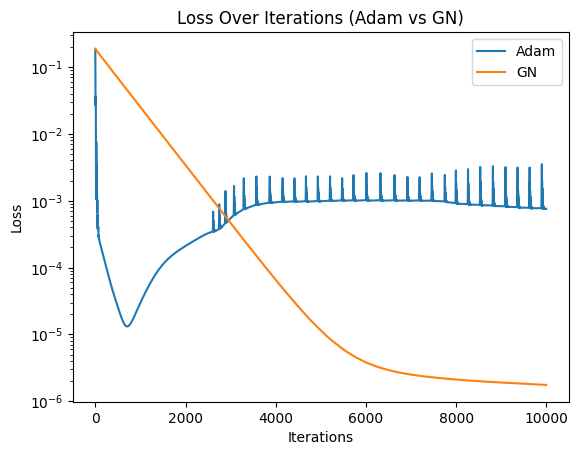

In [76]:
import torch
import matplotlib.pyplot as plt

# Load the loss data
loss_over_iters_adam = torch.load("loss_over_iters_adam.pth")
loss_over_iters_gn = torch.load("loss_over_iters_gn.pth")

# Extract keys (iterations) and values (losses)
adam_iterations = list(loss_over_iters_adam.keys())
adam_values = list(loss_over_iters_adam.values())

gn_iterations = list(loss_over_iters_gn.keys())
gn_values = list(loss_over_iters_gn.values())

# Plot both losses
plt.plot(adam_iterations, adam_values, label="Adam")
plt.plot(gn_iterations, gn_values, label="GN")
plt.semilogy()  # Use logarithmic scale for the y-axis
plt.xlabel("Iterations")
plt.ylabel("Loss")
plt.title("Loss Over Iterations (Adam vs GN)")
plt.legend()
plt.show()
